# Denoiser stresstest

This notebook stresstests the OVITO `ScoreBasedDenoising` modifier on the first CEGANN dataset: labeled perfect grain-boundary POSCARs in `other_data/Grains`.

The workflow is:

1. Load the CEGANN POSCAR-with-labels format directly.
2. Convert one selected structure into a one-frame LAMMPS dump.
3. Cache denoised dumps for the default `0, 1, 2, 3, 4, 8` step ladder under `other_data/denoiser_stresstest`.
4. Compare PTM, adaptive CNA, interval CNA, and fixed-cutoff CNA against the CEGANN binary labels before and after denoising.
5. Plot compact confusion matrices and all-dataset performance tables, then visualize a selected sample side-by-side with rotatable 3D plots.

The CEGANN files contain binary atom labels, but the file itself does not say which value means grain boundary. The metric table reports both direct and inverted-label accuracy and marks the better orientation.
6. Run denoising sanity diagnostics for geometry motion, PTM cutoff sensitivity, and optional scale sweeps.


In [ ]:
#!pip install git+https://github.com/ovito-org/ScoreBasedDenoising.git

In [14]:
# Imports and paths
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
import sys
import zipfile

import numpy as np
import pandas as pd

try:
    from IPython.display import display
except ImportError:
    display = print


def resolve_notebook_dir() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, *cwd.parents):
        if (candidate / "denoiser_stresstest.ipynb").exists():
            return candidate

    known_suffix = Path(
        "autoencode_statmech/lammps/LJ/statistically_independent_samples/"
        "statistically_independent_samples/denoiser_stresstest.ipynb"
    )
    for candidate in (cwd, *cwd.parents):
        known = candidate / known_suffix
        if known.exists():
            return known.parent

    matches = list(cwd.rglob("denoiser_stresstest.ipynb"))
    if matches:
        return matches[0].resolve().parent

    raise FileNotFoundError("Could not locate denoiser_stresstest.ipynb from the current working directory.")


NOTEBOOK_DIR = resolve_notebook_dir()
OTHER_DATA = NOTEBOOK_DIR / "other_data"
GRAINS_DIR = OTHER_DATA / "Grains"
CACHE_DIR = OTHER_DATA / "denoiser_stresstest" / "Grains"

LAMMPSTOOLS_SRC = NOTEBOOK_DIR.parents[2] / "lammpstools" / "src"
if str(LAMMPSTOOLS_SRC) not in sys.path:
    sys.path.insert(0, str(LAMMPSTOOLS_SRC))


pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)

print(f"Notebook dir: {NOTEBOOK_DIR}")
print(f"Grains data:  {GRAINS_DIR}")
print(f"Cache dir:    {CACHE_DIR}")

Notebook dir: /home/jhausberger/Masterthesis/Repos/autoencode_statmech/lammps/LJ/statistically_independent_samples/statistically_independent_samples
Grains data:  /home/jhausberger/Masterthesis/Repos/autoencode_statmech/lammps/LJ/statistically_independent_samples/statistically_independent_samples/other_data/Grains
Cache dir:    /home/jhausberger/Masterthesis/Repos/autoencode_statmech/lammps/LJ/statistically_independent_samples/statistically_independent_samples/other_data/denoiser_stresstest/Grains


In [15]:
# CEGANN Grains dataloader
@dataclass(frozen=True)
class GrainSample:
    family: str
    split: str
    index: int
    path: Path
    labels: np.ndarray
    lattice: np.ndarray
    fractional_positions: np.ndarray
    cartesian_positions: np.ndarray
    species: tuple[str, ...]

    @property
    def natoms(self) -> int:
        return int(self.labels.size)

    @property
    def box_lengths(self) -> np.ndarray:
        return orthorhombic_box_lengths(self.lattice)


def parse_labeled_poscar(path: Path, family: str | None = None, split: str | None = None) -> GrainSample:
    """Parse CEGANN's labeled POSCAR variant.

    The first line is a comma-separated per-atom target vector. The remaining
    file follows the usual POSCAR layout used in the CEGANN pretrained Grains
    data.
    """
    path = Path(path)
    lines = path.read_text().splitlines()
    if len(lines) < 9:
        raise ValueError(f"{path} is too short to be a labeled POSCAR")

    labels = np.fromstring(lines[0].replace(",", " "), sep=" ").astype(np.int8)
    scale = float(lines[1].split()[0])
    lattice = np.array([[float(x) for x in lines[i].split()[:3]] for i in range(2, 5)], dtype=float) * scale

    species_names = lines[5].split()
    counts = [int(float(x)) for x in lines[6].split()]
    if len(species_names) != len(counts):
        raise ValueError(f"Could not parse species/count lines in {path}")
    species = tuple(name for name, count in zip(species_names, counts) for _ in range(count))
    natoms = sum(counts)

    mode_line = lines[7].strip().lower()
    if mode_line.startswith("s"):
        raise NotImplementedError("Selective dynamics POSCARs are not supported in this lightweight parser.")
    is_direct = mode_line.startswith("d")
    is_cartesian = mode_line.startswith("c") or mode_line.startswith("k")
    if not (is_direct or is_cartesian):
        raise ValueError(f"Unsupported coordinate mode '{lines[7]}' in {path}")

    raw_coords = []
    for line in lines[8 : 8 + natoms]:
        raw_coords.append([float(x) for x in line.split()[:3]])
    raw_coords = np.asarray(raw_coords, dtype=float)

    if labels.size != natoms:
        raise ValueError(f"Label count {labels.size} does not match atom count {natoms} in {path}")

    if is_direct:
        fractional = raw_coords % 1.0
        cartesian = fractional @ lattice
    else:
        cartesian = raw_coords * scale
        fractional = cartesian @ np.linalg.inv(lattice)
        fractional = fractional % 1.0

    return GrainSample(
        family=family or path.parents[1].name,
        split=split or path.parent.name,
        index=int(path.stem),
        path=path,
        labels=labels,
        lattice=lattice,
        fractional_positions=fractional,
        cartesian_positions=cartesian,
        species=species,
    )


def ensure_split_extracted(family: str, split: str) -> Path:
    split_dir = GRAINS_DIR / family / split
    if list(split_dir.glob("*.POSCAR")):
        return split_dir

    zip_path = GRAINS_DIR / family / f"{split}.zip"
    if not zip_path.exists():
        raise FileNotFoundError(f"Neither {split_dir} nor {zip_path} exists")

    split_dir.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(zip_path) as zf:
        zf.extractall(GRAINS_DIR / family)
    return split_dir


def build_grains_index(extract_missing: bool = False) -> pd.DataFrame:
    rows = []
    for family_dir in sorted(GRAINS_DIR.glob("*")):
        if not family_dir.is_dir():
            continue
        for split in ("train", "target"):
            split_dir = family_dir / split
            if extract_missing and not list(split_dir.glob("*.POSCAR")) and (family_dir / f"{split}.zip").exists():
                split_dir = ensure_split_extracted(family_dir.name, split)
            for poscar in sorted(split_dir.glob("*.POSCAR"), key=lambda p: int(p.stem) if p.stem.isdigit() else p.stem):
                sample = parse_labeled_poscar(poscar, family=family_dir.name, split=split)
                rows.append({
                    "family": sample.family,
                    "split": sample.split,
                    "index": sample.index,
                    "natoms": sample.natoms,
                    "label_0": int((sample.labels == 0).sum()),
                    "label_1": int((sample.labels == 1).sum()),
                    "path": poscar,
                })
    return pd.DataFrame(rows)


def load_grain_sample(family: str = "fcc", split: str = "train", index: int = 0, extract_missing: bool = True) -> GrainSample:
    split_dir = ensure_split_extracted(family, split) if extract_missing else GRAINS_DIR / family / split
    path = split_dir / f"{index}.POSCAR"
    if not path.exists():
        available = sorted(p.stem for p in split_dir.glob("*.POSCAR"))
        raise FileNotFoundError(f"{path} does not exist. Available POSCAR indices: {available[:20]}")
    return parse_labeled_poscar(path, family=family, split=split)


def orthorhombic_box_lengths(lattice: np.ndarray, atol: float = 1e-8) -> np.ndarray:
    lattice = np.asarray(lattice, dtype=float)
    off_diagonal = lattice - np.diag(np.diag(lattice))
    if not np.allclose(off_diagonal, 0.0, atol=atol):
        raise ValueError("The current LAMMPS dump helper expects an orthorhombic POSCAR cell.")
    return np.abs(np.diag(lattice))


grains_index = build_grains_index(extract_missing=False)
display(grains_index.groupby(["family", "split"], dropna=False).agg(samples=("index", "count"), min_atoms=("natoms", "min"), max_atoms=("natoms", "max")))
display(grains_index.head(20))

samples  min_atoms  max_atoms
family  split                                
bcc     target        1     124434     124434
        train        10       4066       4087
diamond target        1      97567      97567
        train        10       3185       3221
fcc     target        1     104807     104807
        train        10       3847       3877
hcp     target        1      83991      83991
        train        10       2735       2770

,family,split,index,natoms,label_0,label_1,path
0,bcc,train,0,4084,1954,2130,/home/jhausberger/Masterthesis/Repos/autoencod...
1,bcc,train,1,4086,1872,2214,/home/jhausberger/Masterthesis/Repos/autoencod...
2,bcc,train,2,4086,1885,2201,/home/jhausberger/Masterthesis/Repos/autoencod...
3,bcc,train,3,4077,1988,2089,/home/jhausberger/Masterthesis/Repos/autoencod...
4,bcc,train,4,4067,1905,2162,/home/jhausberger/Masterthesis/Repos/autoencod...
5,bcc,train,5,4087,1918,2169,/home/jhausberger/Masterthesis/Repos/autoencod...
6,bcc,train,6,4071,1884,2187,/home/jhausberger/Masterthesis/Repos/autoencod...
7,bcc,train,7,4066,1892,2174,/home/jhausberger/Masterthesis/Repos/autoencod...
8,bcc,train,8,4074,1858,2216,/home/jhausberger/Masterthesis/Repos/autoencod...
9,bcc,train,9,4083,1898,2185,/home/jhausberger/Masterthesis/Repos/autoencod...


In [16]:
# Select the structure for the first Grains stresstest
SELECTED_FAMILY = "fcc"
SELECTED_SPLIT = "train"
SELECTED_INDEX = 0

selected_sample = load_grain_sample(SELECTED_FAMILY, SELECTED_SPLIT, SELECTED_INDEX)

sample_summary = {
    "family": selected_sample.family,
    "split": selected_sample.split,
    "index": selected_sample.index,
    "natoms": selected_sample.natoms,
    "path": selected_sample.path,
    "box_lengths": selected_sample.box_lengths,
    "label_counts": {int(k): int(v) for k, v in zip(*np.unique(selected_sample.labels, return_counts=True))},
}
sample_summary

{'family': 'fcc',
 'split': 'train',
 'index': 0,
 'natoms': 3861,
 'path': PosixPath('/home/jhausberger/Masterthesis/Repos/autoencode_statmech/lammps/LJ/statistically_independent_samples/statistically_independent_samples/other_data/Grains/fcc/train/0.POSCAR'),
 'box_lengths': array([40., 40., 40.]),
 'label_counts': {0: 1754, 1: 2107}}

In [17]:
# LAMMPS dump conversion, denoising cache, and resumable all-Grains denoising
DENOISER_STRUCTURE_BY_FAMILY = {
    "fcc": "FCC",
    "bcc": "BCC",
    "hcp": "HCP",
    # Depending on the installed ScoreBasedDenoising version, diamond may need a different name.
    #"diamond": "Diamond",
}

# Default denoising ladder for all cached data. Visualization uses a smaller subset below.
DENOISE_STEPS = (0, 1, 2, 3, 4, 8)
VISUALIZATION_STEPS = (0, 1, 2, 4)


def sample_cache_dir(sample: GrainSample) -> Path:
    return CACHE_DIR / sample.family / sample.split / f"sample_{sample.index:04d}"


def write_lammps_dump(sample: GrainSample, output_path: Path) -> Path:
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    box = sample.box_lengths
    type_ids = {name: i + 1 for i, name in enumerate(dict.fromkeys(sample.species))}
    positions = sample.cartesian_positions

    with output_path.open("w") as fh:
        fh.write("ITEM: TIMESTEP\n0\n")
        fh.write(f"ITEM: NUMBER OF ATOMS\n{sample.natoms}\n")
        fh.write("ITEM: BOX BOUNDS pp pp pp\n")
        fh.write(f"0.0 {box[0]:.16g}\n")
        fh.write(f"0.0 {box[1]:.16g}\n")
        fh.write(f"0.0 {box[2]:.16g}\n")
        fh.write("ITEM: ATOMS id type x y z\n")
        for atom_id, (species, xyz) in enumerate(zip(sample.species, positions), start=1):
            x, y, z = xyz
            fh.write(f"{atom_id} {type_ids[species]} {x:.16g} {y:.16g} {z:.16g}\n")
    return output_path


def stage_dump_path(sample: GrainSample, steps: int) -> Path:
    suffix = "raw" if int(steps) == 0 else f"denoise_steps_{int(steps):03d}"
    return sample_cache_dir(sample) / f"{suffix}.lammpstrj"


def ensure_raw_dump(sample: GrainSample, force: bool = False) -> Path:
    raw_path = stage_dump_path(sample, 0)
    if force or not raw_path.exists():
        write_lammps_dump(sample, raw_path)
    return raw_path


def available_stage_files(sample: GrainSample, steps=DENOISE_STEPS) -> dict[int, Path]:
    ensure_raw_dump(sample, force=False)
    return {int(s): stage_dump_path(sample, int(s)) for s in steps if stage_dump_path(sample, int(s)).exists()}


def expected_stage_files(sample: GrainSample, steps=DENOISE_STEPS) -> dict[int, Path]:
    ensure_raw_dump(sample, force=False)
    return {int(s): stage_dump_path(sample, int(s)) for s in steps}


def estimate_sample_nn_distance_for_denoiser(sample: GrainSample, max_atoms: int = 4000) -> float:
    """Fast nearest-neighbor estimate for explicit denoiser scale tests."""
    box = sample.box_lengths
    positions = sample.cartesian_positions % box
    if positions.shape[0] > max_atoms:
        rng = np.random.default_rng(0)
        positions = positions[np.sort(rng.choice(positions.shape[0], size=max_atoms, replace=False))]
    try:
        from scipy.spatial import cKDTree

        tree = cKDTree(positions, boxsize=box)
        distances, _ = tree.query(positions, k=2, workers=-1)
        return float(np.median(distances[:, 1]))
    except Exception:
        # Quadratic fallback, kept bounded by max_atoms above.
        mins = []
        for i in range(positions.shape[0]):
            delta = positions - positions[i]
            delta -= box * np.round(delta / box)
            distance = np.linalg.norm(delta, axis=1)
            distance[i] = np.inf
            mins.append(distance.min())
        return float(np.median(mins))


def resolve_denoiser_scale(sample: GrainSample, scale: float | str | None) -> float | None:
    if scale is None:
        return None
    if isinstance(scale, str):
        if scale == "sample_nn":
            return estimate_sample_nn_distance_for_denoiser(sample)
        raise ValueError(f"Unknown scale mode {scale!r}; use None, a float, or 'sample_nn'.")
    return float(scale)


def _write_denoised_stage_atomic(
    raw_path: Path,
    output_path: Path,
    structure: str,
    step_count: int,
    device: str,
    scale: float | None,
    model_path: str | Path | None,
) -> Path:
    from lammpstools.denoise_calc import write_denoised_lammpstrj

    output_path = Path(output_path)
    tmp_path = output_path.with_name(output_path.name + ".tmp")
    if tmp_path.exists():
        tmp_path.unlink()

    write_denoised_lammpstrj(
        input_filename=raw_path,
        output_filename=tmp_path,
        structure=structure,
        steps=step_count,
        device=device,
        scale=scale,
        model_path=model_path,
    )
    tmp_path.replace(output_path)
    return output_path


def ensure_denoising_ladder(
    sample: GrainSample,
    steps=DENOISE_STEPS,
    force: bool = False,
    run_missing: bool = True,
    device: str = "cpu",
    scale: float | str | None = None,
    model_path: str | Path | None = None,
    structure: str | None = None,
) -> dict[int, Path]:
    """Create or reuse cached denoised dumps for several denoising step counts.

    This function is restart-friendly: each completed denoised step is saved to
    disk immediately. A step is first written to `*.tmp` and only moved to the
    final filename after the OVITO export finishes.
    """
    raw_path = ensure_raw_dump(sample, force=force)
    structure = structure or DENOISER_STRUCTURE_BY_FAMILY.get(sample.family, sample.family.upper())
    resolved_scale = resolve_denoiser_scale(sample, scale)

    positive_steps = sorted({int(s) for s in steps if int(s) > 0})
    outputs: dict[int, Path] = {0: raw_path}
    missing_steps = []
    for step_count in positive_steps:
        output_path = stage_dump_path(sample, step_count)
        outputs[step_count] = output_path
        if force or not output_path.exists():
            missing_steps.append(step_count)

    if missing_steps and run_missing:
        for step_count in missing_steps:
            _write_denoised_stage_atomic(
                raw_path=raw_path,
                output_path=outputs[step_count],
                structure=structure,
                step_count=step_count,
                device=device,
                scale=resolved_scale,
                model_path=model_path,
            )
    return outputs


def scale_variant_stage_path(sample: GrainSample, scale_tag: str, steps: int) -> Path:
    suffix = "raw" if int(steps) == 0 else f"denoise_steps_{int(steps):03d}"
    return sample_cache_dir(sample) / "scale_sweep" / scale_tag / f"{suffix}.lammpstrj"


def ensure_scale_variant_ladder(
    sample: GrainSample,
    scale: float | str | None,
    steps=DENOISE_STEPS,
    force: bool = False,
    device: str = "cpu",
    model_path: str | Path | None = None,
    structure: str | None = None,
    tag: str | None = None,
) -> dict[int, Path]:
    """Cache a selected-sample denoising run under a parameter-specific folder."""
    raw_path = ensure_raw_dump(sample, force=False)
    resolved_scale = resolve_denoiser_scale(sample, scale)
    if tag is None:
        tag = "scale_auto" if resolved_scale is None else f"scale_{resolved_scale:.4f}".replace(".", "p")
    structure = structure or DENOISER_STRUCTURE_BY_FAMILY.get(sample.family, sample.family.upper())

    outputs = {0: raw_path}
    for step_count in sorted({int(s) for s in steps if int(s) > 0}):
        output_path = scale_variant_stage_path(sample, tag, step_count)
        outputs[step_count] = output_path
        if output_path.exists() and not force:
            continue
        _write_denoised_stage_atomic(
            raw_path=raw_path,
            output_path=output_path,
            structure=structure,
            step_count=step_count,
            device=device,
            scale=resolved_scale,
            model_path=model_path,
        )
    return outputs


def iter_grain_samples(
    families: tuple[str, ...] | None = None,
    splits: tuple[str, ...] = ("train", "target"),
    max_samples: int | None = None,
    max_atoms: int | None = None,
):
    """Yield Grains samples one at a time so large systems are never accumulated."""
    index = build_grains_index(extract_missing=True).sort_values(["family", "split", "index"])
    if families is not None:
        index = index[index["family"].isin(families)]
    if splits is not None:
        index = index[index["split"].isin(splits)]
    if max_atoms is not None:
        index = index[index["natoms"] <= int(max_atoms)]
    if max_samples is not None:
        index = index.head(int(max_samples))

    for row in index.itertuples(index=False):
        yield load_grain_sample(row.family, row.split, int(row.index), extract_missing=True)


def denoise_missing_grains(
    steps=DENOISE_STEPS,
    families: tuple[str, ...] | None = None,
    splits: tuple[str, ...] = ("train", "target"),
    max_samples: int | None = None,
    max_atoms: int | None = None,
    force: bool = False,
    device: str = "cpu",
    scale: float | None = None,
    model_path: str | Path | None = None,
) -> pd.DataFrame:
    """Run missing denoising stages for all selected Grains samples.

    Safe to stop and restart. Already-finished final files are reused, and only
    one `GrainSample` plus one OVITO pipeline is processed at a time.
    """
    rows = []
    for sample in iter_grain_samples(families=families, splits=splits, max_samples=max_samples, max_atoms=max_atoms):
        before = expected_stage_files(sample, steps=steps)
        missing_before = [s for s, path in before.items() if s > 0 and (force or not path.exists())]
        row = {
            "dataset": f"{sample.family}/{sample.split}/{sample.index}",
            "family": sample.family,
            "split": sample.split,
            "index": sample.index,
            "natoms": sample.natoms,
            "missing_before": tuple(missing_before),
            "status": "skipped_existing" if not missing_before else "pending",
        }
        try:
            outputs = ensure_denoising_ladder(
                sample,
                steps=steps,
                force=force,
                run_missing=True,
                device=device,
                scale=scale,
                model_path=model_path,
            )
            row["available_after"] = tuple(sorted(s for s, path in outputs.items() if path.exists()))
            row["status"] = "ok"
        except KeyboardInterrupt:
            row["status"] = "interrupted"
            rows.append(row)
            print("Interrupted after saving completed stages. Re-run this cell to continue.")
            return pd.DataFrame(rows)
        except Exception as exc:
            row["status"] = "failed"
            row["error"] = f"{type(exc).__name__}: {exc}"
        rows.append(row)
        print(f"{row['dataset']}: {row['status']} missing_before={row['missing_before']}")
    return pd.DataFrame(rows)


# Selected-sample cache. This is cheap and keeps the visualization section immediately usable.
FORCE_DENOISE = False
RUN_MISSING_DENOISE = True
DENOISE_DEVICE = "cpu"
# None lets OVITO estimate the nearest-neighbor distance. Use "sample_nn" to pass
# the raw sample median nearest-neighbor distance explicitly.
DENOISE_SCALE = None
DENOISE_MODEL_PATH = None

try:
    cached_stage_files = ensure_denoising_ladder(
        selected_sample,
        steps=DENOISE_STEPS,
        force=FORCE_DENOISE,
        run_missing=RUN_MISSING_DENOISE,
        device=DENOISE_DEVICE,
        scale=DENOISE_SCALE,
        model_path=DENOISE_MODEL_PATH,
    )
except ImportError as exc:
    print(exc)
    print("Continuing with cached stages that already exist, plus the raw dump.")
    cached_stage_files = available_stage_files(selected_sample, DENOISE_STEPS)

pd.DataFrame(
    [{"steps": steps, "exists": path.exists(), "path": path} for steps, path in cached_stage_files.items()]
).sort_values("steps")

Estimated nearest neighbor distance = 2.88 A
Iteration: 1/8: 1.21 s
Iteration: 2/8: 1.05 s
Iteration: 3/8: 0.919 s
Iteration: 4/8: 0.905 s
Iteration: 5/8: 0.891 s
Iteration: 6/8: 0.870 s
Iteration: 7/8: 0.903 s
Iteration: 8/8: 0.895 s


,steps,exists,path
0,0,True,/home/jhausberger/Masterthesis/Repos/autoencod...
1,1,True,/home/jhausberger/Masterthesis/Repos/autoencod...
2,2,True,/home/jhausberger/Masterthesis/Repos/autoencod...
3,3,True,/home/jhausberger/Masterthesis/Repos/autoencod...
4,4,True,/home/jhausberger/Masterthesis/Repos/autoencod...
5,8,True,/home/jhausberger/Masterthesis/Repos/autoencod...


In [18]:
# Optional: run missing denoising stages across all Grains data
# Set RUN_ALL_MISSING_DENOISE=True when you want to launch the full resumable cache fill.
# You can interrupt this cell and re-run it later; completed step files are kept.
RUN_ALL_MISSING_DENOISE = True
ALL_DENOISE_FAMILIES = None          # e.g. ("fcc", "hcp")
ALL_DENOISE_SPLITS = ("train", "target")
ALL_DENOISE_MAX_SAMPLES = None       # useful for a quick test
ALL_DENOISE_MAX_ATOMS = None         # set e.g. 10000 to skip huge systems while testing
ALL_DENOISE_FORCE = False            # True deliberately regenerates existing denoised stages

if RUN_ALL_MISSING_DENOISE:
    all_denoise_status = denoise_missing_grains(
        steps=DENOISE_STEPS,
        families=ALL_DENOISE_FAMILIES,
        splits=ALL_DENOISE_SPLITS,
        max_samples=ALL_DENOISE_MAX_SAMPLES,
        max_atoms=ALL_DENOISE_MAX_ATOMS,
        force=ALL_DENOISE_FORCE,
        device=DENOISE_DEVICE,
        scale=DENOISE_SCALE,
        model_path=DENOISE_MODEL_PATH,
    )
else:
    all_denoise_status = pd.DataFrame()
    print("Full all-Grains denoising is disabled. Set RUN_ALL_MISSING_DENOISE=True to run it.")

all_denoise_status

Estimated nearest neighbor distance = 2.72 A
Iteration: 1/8: 33.9 s
Iteration: 2/8: 27.2 s
Iteration: 3/8: 25.4 s
Iteration: 4/8: 25.2 s
Iteration: 5/8: 25.2 s
Iteration: 6/8: 25.4 s
Iteration: 7/8: 25.5 s
Iteration: 8/8: 26.4 s
bcc/target/0: ok missing_before=(8,)
Estimated nearest neighbor distance = 2.71 A
Iteration: 1/8: 0.799 s
Iteration: 2/8: 0.733 s
Iteration: 3/8: 0.629 s
Iteration: 4/8: 0.910 s
Iteration: 5/8: 0.677 s
Iteration: 6/8: 0.677 s
Iteration: 7/8: 0.710 s
Iteration: 8/8: 0.638 s
bcc/train/0: ok missing_before=(8,)
Estimated nearest neighbor distance = 2.71 A
Iteration: 1/8: 0.707 s
Iteration: 2/8: 0.753 s
Iteration: 3/8: 0.685 s
Iteration: 4/8: 0.671 s
Iteration: 5/8: 0.661 s
Iteration: 6/8: 0.626 s
Iteration: 7/8: 0.629 s
Iteration: 8/8: 0.614 s
bcc/train/1: ok missing_before=(8,)
Estimated nearest neighbor distance = 2.71 A
Iteration: 1/8: 0.793 s
Iteration: 2/8: 0.749 s
Iteration: 3/8: 0.621 s
Iteration: 4/8: 0.623 s
Iteration: 5/8: 0.611 s
Iteration: 6/8: 0.626 s

,dataset,family,split,index,natoms,missing_before,status,available_after,error
0,bcc/target/0,bcc,target,0,124434,"(8,)",ok,"(0, 1, 2, 3, 4, 8)",NaN
1,bcc/train/0,bcc,train,0,4084,"(8,)",ok,"(0, 1, 2, 3, 4, 8)",NaN
2,bcc/train/1,bcc,train,1,4086,"(8,)",ok,"(0, 1, 2, 3, 4, 8)",NaN
3,bcc/train/2,bcc,train,2,4086,"(8,)",ok,"(0, 1, 2, 3, 4, 8)",NaN
4,bcc/train/3,bcc,train,3,4077,"(8,)",ok,"(0, 1, 2, 3, 4, 8)",NaN
5,bcc/train/4,bcc,train,4,4067,"(8,)",ok,"(0, 1, 2, 3, 4, 8)",NaN
6,bcc/train/5,bcc,train,5,4087,"(8,)",ok,"(0, 1, 2, 3, 4, 8)",NaN
7,bcc/train/6,bcc,train,6,4071,"(8,)",ok,"(0, 1, 2, 3, 4, 8)",NaN
8,bcc/train/7,bcc,train,7,4066,"(8,)",ok,"(0, 1, 2, 3, 4, 8)",NaN
9,bcc/train/8,bcc,train,8,4074,"(8,)",ok,"(0, 1, 2, 3, 4, 8)",NaN


In [19]:
# PTM/CNA descriptor evaluation, confusion matrices, and all-dataset performance tables
EXPECTED_OVITO_STRUCTURE_TYPE = {
    "fcc": 1,
    "hcp": 2,
    "bcc": 3,
    "diamond": 5,  # PTM cubic-diamond structure type. CNA does not support diamond here.
}

FIXED_CNA_NN_FACTOR = {
    "fcc": 1.207,
    "hcp": 1.207,
    "bcc": 1.077,
}

DESCRIPTOR_METHODS = ("ptm", "cna_adaptive", "cna_interval", "cna_fixed")


def supported_descriptor_methods(sample: GrainSample, methods=DESCRIPTOR_METHODS) -> tuple[str, ...]:
    if sample.family == "diamond":
        return tuple(method for method in methods if method == "ptm")
    return tuple(methods)


def _particle_ids_and_structure_types(data):
    particles = data.particles
    structure_type = np.asarray(particles["Structure Type"], dtype=np.int16)
    if "Particle Identifier" in particles:
        ids = np.asarray(particles["Particle Identifier"], dtype=np.int64)
    else:
        ids = np.arange(1, structure_type.size + 1, dtype=np.int64)
    order = np.argsort(ids)
    return ids[order], structure_type[order]


def compute_ptm_structure_types(filename: Path, rmsd_cutoff: float = 0.1) -> np.ndarray:
    from ovito.io import import_file
    from ovito.modifiers import PolyhedralTemplateMatchingModifier

    pipeline = import_file(str(filename), multiple_frames=True)
    pipeline.modifiers.append(
        PolyhedralTemplateMatchingModifier(
            output_rmsd=True,
            output_interatomic_distance=True,
            output_orientation=True,
            rmsd_cutoff=float(rmsd_cutoff),
        )
    )
    _, structure_type = _particle_ids_and_structure_types(pipeline.compute(0))
    return structure_type


def compute_cna_structure_types(filename: Path, mode: str, fixed_cutoff: float | None = None) -> np.ndarray:
    from ovito.io import import_file
    from ovito.modifiers import CommonNeighborAnalysisModifier

    mode_lookup = {
        "cna_fixed": CommonNeighborAnalysisModifier.Mode.FixedCutoff,
        "cna_adaptive": CommonNeighborAnalysisModifier.Mode.AdaptiveCutoff,
        "cna_interval": CommonNeighborAnalysisModifier.Mode.IntervalCutoff,
    }
    if mode not in mode_lookup:
        raise ValueError(f"Unknown CNA mode {mode!r}")

    kwargs = {"mode": mode_lookup[mode]}
    if mode == "cna_fixed":
        if fixed_cutoff is None:
            raise ValueError("fixed_cutoff is required for fixed CNA")
        kwargs["cutoff"] = float(fixed_cutoff)

    pipeline = import_file(str(filename), multiple_frames=True)
    pipeline.modifiers.append(CommonNeighborAnalysisModifier(**kwargs))
    _, structure_type = _particle_ids_and_structure_types(pipeline.compute(0))
    return structure_type


def estimate_nearest_neighbor_distance(sample: GrainSample, max_atoms_for_fallback: int = 2500) -> float:
    box = sample.box_lengths
    positions = sample.cartesian_positions % box
    try:
        from scipy.spatial import cKDTree

        tree = cKDTree(positions, boxsize=box)
        distances, _ = tree.query(positions, k=2, workers=-1)
        return float(np.median(distances[:, 1]))
    except Exception:
        rng = np.random.default_rng(0)
        if positions.shape[0] > max_atoms_for_fallback:
            keep = rng.choice(positions.shape[0], size=max_atoms_for_fallback, replace=False)
            positions = positions[keep]
        delta = positions[:, None, :] - positions[None, :, :]
        delta -= box * np.round(delta / box)
        distances = np.linalg.norm(delta, axis=-1)
        np.fill_diagonal(distances, np.inf)
        return float(np.median(np.min(distances, axis=1)))


def fixed_cna_cutoff_for_sample(sample: GrainSample) -> float:
    nn = estimate_nearest_neighbor_distance(sample)
    return nn * FIXED_CNA_NN_FACTOR.get(sample.family, 1.2)


def compute_descriptor_structure_types(
    sample: GrainSample,
    filename: Path,
    method: str,
    ptm_rmsd_cutoff: float = 0.1,
    fixed_cna_cutoff: float | None = None,
) -> np.ndarray:
    if method == "ptm":
        return compute_ptm_structure_types(filename, rmsd_cutoff=ptm_rmsd_cutoff)
    if method == "cna_fixed":
        fixed_cna_cutoff = fixed_cna_cutoff if fixed_cna_cutoff is not None else fixed_cna_cutoff_for_sample(sample)
        return compute_cna_structure_types(filename, "cna_fixed", fixed_cutoff=fixed_cna_cutoff)
    if method in {"cna_adaptive", "cna_interval"}:
        return compute_cna_structure_types(filename, method)
    raise ValueError(f"Unknown descriptor method {method!r}")


def predict_boundary_from_structure_types(sample: GrainSample, structure_type: np.ndarray) -> np.ndarray:
    expected_type = EXPECTED_OVITO_STRUCTURE_TYPE[sample.family]
    return np.asarray(structure_type != expected_type, dtype=np.int8)


def labels_to_boundary(labels: np.ndarray, mapping: str) -> np.ndarray:
    labels = np.asarray(labels, dtype=np.int8)
    if mapping == "label_1_is_boundary":
        return labels
    if mapping == "label_0_is_boundary":
        return 1 - labels
    raise ValueError(f"Unknown label mapping {mapping!r}")


def infer_label_mapping(predicted_boundary: np.ndarray, labels: np.ndarray) -> str:
    predicted_boundary = np.asarray(predicted_boundary, dtype=np.int8)
    labels = np.asarray(labels, dtype=np.int8)
    direct = float(np.mean(predicted_boundary == labels))
    inverted = float(np.mean(predicted_boundary == (1 - labels)))
    return "label_1_is_boundary" if direct >= inverted else "label_0_is_boundary"


def binary_confusion(true_boundary: np.ndarray, predicted_boundary: np.ndarray) -> np.ndarray:
    true_boundary = np.asarray(true_boundary, dtype=np.int8)
    predicted_boundary = np.asarray(predicted_boundary, dtype=np.int8)
    return np.array(
        [
            [int(np.sum((true_boundary == 0) & (predicted_boundary == 0))), int(np.sum((true_boundary == 0) & (predicted_boundary == 1)))],
            [int(np.sum((true_boundary == 1) & (predicted_boundary == 0))), int(np.sum((true_boundary == 1) & (predicted_boundary == 1)))],
        ],
        dtype=int,
    )


def binary_descriptor_metrics(predicted_boundary: np.ndarray, labels: np.ndarray, label_mapping: str | None = None) -> dict[str, float | str]:
    predicted_boundary = np.asarray(predicted_boundary, dtype=np.int8)
    labels = np.asarray(labels, dtype=np.int8)
    direct = float(np.mean(predicted_boundary == labels))
    inverted = float(np.mean(predicted_boundary == (1 - labels)))
    if label_mapping is None:
        label_mapping = infer_label_mapping(predicted_boundary, labels)
    true_boundary = labels_to_boundary(labels, label_mapping)
    confusion = binary_confusion(true_boundary, predicted_boundary)
    tn, fp, fn, tp = confusion.ravel()
    accuracy = float((tp + tn) / max(confusion.sum(), 1))
    sensitivity = float(tp / (tp + fn)) if (tp + fn) else np.nan
    specificity = float(tn / (tn + fp)) if (tn + fp) else np.nan
    balanced = float(np.nanmean([sensitivity, specificity]))
    return {
        "accuracy": accuracy,
        "balanced_accuracy": balanced,
        "direct_accuracy": direct,
        "inverted_accuracy": inverted,
        "best_accuracy": max(direct, inverted),
        "label_mapping": label_mapping,
        "predicted_boundary_fraction": float(np.mean(predicted_boundary)),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
    }


def evaluate_descriptor_ladder(
    sample: GrainSample,
    stage_files: dict[int, Path],
    methods=DESCRIPTOR_METHODS,
    ptm_rmsd_cutoff: float = 0.1,
    fixed_cna_cutoff: float | None = None,
    reference_step: int = 0,
) -> pd.DataFrame:
    if sample.family not in EXPECTED_OVITO_STRUCTURE_TYPE:
        raise ValueError(f"No expected OVITO structure type is configured for family {sample.family!r}")

    fixed_cna_cutoff = fixed_cna_cutoff if fixed_cna_cutoff is not None else fixed_cna_cutoff_for_sample(sample)
    labels = sample.labels.astype(np.int8)
    methods = supported_descriptor_methods(sample, methods)
    rows = []
    mapping_by_method = {}

    # First pass on the reference step fixes the unknown binary-label orientation.
    if reference_step in stage_files and Path(stage_files[reference_step]).exists():
        for method in methods:
            structure_type = compute_descriptor_structure_types(sample, stage_files[reference_step], method, ptm_rmsd_cutoff, fixed_cna_cutoff)
            predicted_boundary = predict_boundary_from_structure_types(sample, structure_type)
            mapping_by_method[method] = infer_label_mapping(predicted_boundary, labels)

    for steps, filename in sorted(stage_files.items()):
        if not Path(filename).exists():
            continue
        for method in methods:
            structure_type = compute_descriptor_structure_types(sample, filename, method, ptm_rmsd_cutoff, fixed_cna_cutoff)
            if structure_type.size != labels.size:
                raise ValueError(f"{method} returned {structure_type.size} atoms, expected {labels.size}")
            predicted_boundary = predict_boundary_from_structure_types(sample, structure_type)
            label_mapping = mapping_by_method.get(method) or infer_label_mapping(predicted_boundary, labels)
            row = {
                "dataset": f"{sample.family}/{sample.split}/{sample.index}",
                "family": sample.family,
                "split": sample.split,
                "index": sample.index,
                "natoms": sample.natoms,
                "steps": int(steps),
                "method": method,
                "expected_type": int(EXPECTED_OVITO_STRUCTURE_TYPE[sample.family]),
                "other_fraction": float(np.mean(structure_type == 0)),
                "fixed_cna_cutoff": float(fixed_cna_cutoff),
                "path": filename,
            }
            row.update(binary_descriptor_metrics(predicted_boundary, labels, label_mapping=label_mapping))
            rows.append(row)

    return pd.DataFrame(rows).sort_values(["method", "steps"]).reset_index(drop=True)


def evaluate_all_grains_performance(
    denoised_step: int = max(DENOISE_STEPS),
    families: tuple[str, ...] | None = None,
    splits: tuple[str, ...] = ("train", "target"),
    max_samples: int | None = None,
    max_atoms: int | None = None,
    methods=DESCRIPTOR_METHODS,
) -> pd.DataFrame:
    """Aggregate untouched-vs-denoised descriptor performance per Grains family.

    Each row is one logical dataset such as `Grains/fcc`, not one POSCAR. The
    reported accuracies are atom-weighted over all selected samples that have
    both the raw and requested denoised-stage cache files.
    """
    sample_rows = []
    for sample in iter_grain_samples(families=families, splits=splits, max_samples=max_samples, max_atoms=max_atoms):
        stages = expected_stage_files(sample, steps=(0, denoised_step))
        supported_methods = supported_descriptor_methods(sample, methods)
        if not stages[denoised_step].exists():
            for method in supported_methods:
                sample_rows.append({
                    "family": sample.family,
                    "method": method,
                    "natoms": sample.natoms,
                    "status": f"missing denoised step {denoised_step}",
                    "is_usable": False,
                })
            continue
        try:
            ladder = evaluate_descriptor_ladder(sample, stages, methods=methods)
            for method in sorted(ladder["method"].unique()):
                method_rows = ladder[ladder["method"] == method].set_index("steps")
                if 0 not in method_rows.index or denoised_step not in method_rows.index:
                    sample_rows.append({
                        "family": sample.family,
                        "method": method,
                        "natoms": sample.natoms,
                        "status": "missing evaluated step",
                        "is_usable": False,
                    })
                    continue

                raw = method_rows.loc[0]
                denoised = method_rows.loc[denoised_step]
                sample_rows.append({
                    "family": sample.family,
                    "method": method,
                    "natoms": sample.natoms,
                    "raw_correct": int(raw["tn"] + raw["tp"]),
                    "raw_total": int(raw["tn"] + raw["fp"] + raw["fn"] + raw["tp"]),
                    "denoised_correct": int(denoised["tn"] + denoised["tp"]),
                    "denoised_total": int(denoised["tn"] + denoised["fp"] + denoised["fn"] + denoised["tp"]),
                    "denoised_step": denoised_step,
                    "label_mapping": raw["label_mapping"],
                    "status": "ok",
                    "is_usable": True,
                })
        except KeyboardInterrupt:
            print("Interrupted after finishing the previous dataset. Re-run this cell to continue.")
            break
        except Exception as exc:
            for method in supported_methods:
                sample_rows.append({
                    "family": sample.family,
                    "method": method,
                    "natoms": sample.natoms,
                    "status": "failed",
                    "error": f"{type(exc).__name__}: {exc}",
                    "is_usable": False,
                })

    sample_table = pd.DataFrame(sample_rows)
    if sample_table.empty:
        return sample_table

    rows = []
    for (family, method), group in sample_table.groupby(["family", "method"], sort=True):
        usable = group[group["is_usable"]]
        missing = group[~group["is_usable"]]
        row = {
            "dataset": f"Grains/{family}",
            "family": family,
            "method": method,
            "samples_used": int(len(usable)),
            "samples_missing": int(len(missing)),
            "natoms_used": int(usable["natoms"].sum()) if not usable.empty else 0,
            "denoised_step": denoised_step,
        }
        if usable.empty:
            row.update({
                "accuracy_untouched": np.nan,
                "accuracy_denoised": np.nan,
                "change": np.nan,
                "status": "; ".join(sorted(set(missing["status"].astype(str)))) or "missing",
            })
        else:
            raw_correct = int(usable["raw_correct"].sum())
            raw_total = int(usable["raw_total"].sum())
            denoised_correct = int(usable["denoised_correct"].sum())
            denoised_total = int(usable["denoised_total"].sum())
            raw_acc = raw_correct / raw_total if raw_total else np.nan
            denoised_acc = denoised_correct / denoised_total if denoised_total else np.nan
            status = "ok" if missing.empty else f"partial: {len(missing)} sample(s) missing/failed"
            row.update({
                "accuracy_untouched": raw_acc,
                "accuracy_denoised": denoised_acc,
                "change": denoised_acc - raw_acc,
                "status": status,
            })
        rows.append(row)
    return pd.DataFrame(rows).sort_values(["method", "dataset"]).reset_index(drop=True)


def style_performance_table(table: pd.DataFrame):
    if table.empty:
        return table
    columns = ["dataset", "accuracy_untouched", "accuracy_denoised", "change", "status"]
    visible = [col for col in columns if col in table.columns]
    styled = table[visible].style.format({
        "accuracy_untouched": "{:.3f}",
        "accuracy_denoised": "{:.3f}",
        "change": "{:+.3f}",
    })
    if "change" in table.columns:
        styled = styled.background_gradient(subset=["change"], cmap="RdYlGn", vmin=-0.25, vmax=0.25)
    return styled


def plot_confusion_matrices(
    sample: GrainSample,
    stage_files: dict[int, Path],
    methods=DESCRIPTOR_METHODS,
    steps=(0, 1, 2, 3, 4),
    ptm_rmsd_cutoff: float = 0.1,
):
    import matplotlib.pyplot as plt

    methods = supported_descriptor_methods(sample, methods)
    steps = tuple(step for step in steps if step in stage_files and Path(stage_files[step]).exists())
    if not steps:
        raise ValueError("No requested denoising-step files exist for confusion plotting.")

    fixed_cna_cutoff = fixed_cna_cutoff_for_sample(sample)
    label_mapping_by_method = {}
    for method in methods:
        ref_step = 0 if 0 in stage_files and Path(stage_files[0]).exists() else steps[0]
        ref_type = compute_descriptor_structure_types(sample, stage_files[ref_step], method, ptm_rmsd_cutoff, fixed_cna_cutoff)
        ref_pred = predict_boundary_from_structure_types(sample, ref_type)
        label_mapping_by_method[method] = infer_label_mapping(ref_pred, sample.labels)

    fig, axes = plt.subplots(len(methods), len(steps), figsize=(2.25 * len(steps), 2.25 * len(methods)), squeeze=False)
    for row_idx, method in enumerate(methods):
        true_boundary = labels_to_boundary(sample.labels, label_mapping_by_method[method])
        for col_idx, step in enumerate(steps):
            ax = axes[row_idx, col_idx]
            structure_type = compute_descriptor_structure_types(sample, stage_files[step], method, ptm_rmsd_cutoff, fixed_cna_cutoff)
            pred_boundary = predict_boundary_from_structure_types(sample, structure_type)
            cm = binary_confusion(true_boundary, pred_boundary)
            acc = (cm[0, 0] + cm[1, 1]) / cm.sum()
            ax.imshow(cm, cmap="Blues")
            for i in range(2):
                for j in range(2):
                    ax.text(j, i, str(cm[i, j]), ha="center", va="center", color="black", fontsize=8)
            ax.set_xticks([0, 1], labels=["bulk", "GB"], fontsize=7)
            ax.set_yticks([0, 1], labels=["bulk", "GB"], fontsize=7)
            if row_idx == 0:
                ax.set_title(f"steps {step}\nacc {acc:.3f}", fontsize=9)
            else:
                ax.set_title(f"acc {acc:.3f}", fontsize=9)
            if col_idx == 0:
                ax.set_ylabel(method, fontsize=9)
            ax.tick_params(length=0)
    fig.suptitle(f"{sample.family}/{sample.split}/{sample.index}: true rows, predicted columns", y=1.02, fontsize=11)
    fig.tight_layout()
    return fig


try:
    metrics = evaluate_descriptor_ladder(selected_sample, cached_stage_files)
    display(metrics)
    display(metrics.pivot(index="steps", columns="method", values="accuracy"))
except ImportError as exc:
    print("OVITO is required for PTM/CNA evaluation:", exc)
    metrics = pd.DataFrame()
except Exception as exc:
    print("Descriptor evaluation failed:", type(exc).__name__, exc)
    metrics = pd.DataFrame()

,dataset,family,split,index,natoms,steps,method,expected_type,other_fraction,fixed_cna_cutoff,path,accuracy,balanced_accuracy,direct_accuracy,inverted_accuracy,best_accuracy,label_mapping,predicted_boundary_fraction,tn,fp,fn,tp
0,fcc/train/0,fcc,train,0,3861,0,cna_adaptive,1,0.454027,3.453991,/home/jhausberger/Masterthesis/Repos/autoencod...,1.000000,1.000000,0.000000,1.000000,1.000000,label_0_is_boundary,0.454286,2107,0,0,1754
1,fcc/train/0,fcc,train,0,3861,1,cna_adaptive,1,0.453250,3.453991,/home/jhausberger/Masterthesis/Repos/autoencod...,0.986273,0.986181,0.013727,0.986273,0.986273,label_0_is_boundary,0.454545,2080,27,26,1728
2,fcc/train/0,fcc,train,0,3861,2,cna_adaptive,1,0.474747,3.453991,/home/jhausberger/Masterthesis/Repos/autoencod...,0.961409,0.963066,0.038591,0.961409,0.961409,label_0_is_boundary,0.475783,1991,116,33,1721
3,fcc/train/0,fcc,train,0,3861,3,cna_adaptive,1,0.480186,3.453991,/home/jhausberger/Masterthesis/Repos/autoencod...,0.950272,0.952432,0.049728,0.950272,0.950272,label_0_is_boundary,0.482258,1957,150,42,1712
4,fcc/train/0,fcc,train,0,3861,4,cna_adaptive,1,0.488215,3.453991,/home/jhausberger/Masterthesis/Repos/autoencod...,0.938358,0.941277,0.061642,0.938358,0.938358,label_0_is_boundary,0.491582,1916,191,47,1707
5,fcc/train/0,fcc,train,0,3861,8,cna_adaptive,1,0.499611,3.453991,/home/jhausberger/Masterthesis/Repos/autoencod...,0.917120,0.921340,0.082880,0.917120,0.917120,label_0_is_boundary,0.507641,1844,263,57,1697
6,fcc/train/0,fcc,train,0,3861,0,cna_fixed,1,0.471380,3.453991,/home/jhausberger/Masterthesis/Repos/autoencod...,0.982647,0.984101,0.017353,0.982647,0.982647,label_0_is_boundary,0.471639,2040,67,0,1754
7,fcc/train/0,fcc,train,0,3861,1,cna_fixed,1,0.463869,3.453991,/home/jhausberger/Masterthesis/Repos/autoencod...,0.980834,0.981628,0.019166,0.980834,0.980834,label_0_is_boundary,0.464646,2050,57,17,1737
8,fcc/train/0,fcc,train,0,3861,2,cna_fixed,1,0.484848,3.453991,/home/jhausberger/Masterthesis/Repos/autoencod...,0.956747,0.959272,0.043253,0.956747,0.956747,label_0_is_boundary,0.485625,1963,144,23,1731
9,fcc/train/0,fcc,train,0,3861,3,cna_fixed,1,0.493136,3.453991,/home/jhausberger/Masterthesis/Repos/autoencod...,0.945351,0.948592,0.054649,0.945351,0.945351,label_0_is_boundary,0.494431,1924,183,28,1726


method,cna_adaptive,cna_fixed,cna_interval,ptm
steps,,,,
0,1.000000,0.982647,0.991971,0.987568
1,0.986273,0.980834,0.981352,0.978244
2,0.961409,0.956747,0.968402,0.970474
3,0.950272,0.945351,0.961409,0.966071
4,0.938358,0.930329,0.950531,0.958301
8,0.917120,0.907019,0.928775,0.934732


In [ ]:
# Denoising sanity diagnostics: geometry motion, scale sweep, and PTM cutoff sensitivity
# These checks are meant to answer: did denoising physically move atoms too much,
# or did the descriptor cutoff become too strict after small coordinate changes?

def read_lammpstrj_positions(filename: Path, frame: int = 0) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    lines = Path(filename).read_text().splitlines()
    frame_counter = -1
    i = 0
    natoms = None
    box = None
    while i < len(lines):
        if lines[i].startswith("ITEM: TIMESTEP"):
            frame_counter += 1
            i += 2
            continue
        if lines[i].startswith("ITEM: NUMBER OF ATOMS"):
            natoms = int(lines[i + 1].strip())
            i += 2
            continue
        if lines[i].startswith("ITEM: BOX BOUNDS"):
            bounds = np.array([[float(x) for x in lines[i + 1 + j].split()[:2]] for j in range(3)])
            box = bounds[:, 1] - bounds[:, 0]
            i += 4
            continue
        if lines[i].startswith("ITEM: ATOMS"):
            columns = lines[i].split()[2:]
            if frame_counter == frame:
                table = np.array([[float(x) for x in row.split()] for row in lines[i + 1 : i + 1 + natoms]], dtype=float)
                col = {name: idx for idx, name in enumerate(columns)}
                ids = table[:, col.get("id", col.get("Particle Identifier", 0))].astype(int)
                xyz_columns = [col.get(name) for name in ("x", "y", "z")]
                if any(idx is None for idx in xyz_columns):
                    xyz_columns = [col[name] for name in ("Position.X", "Position.Y", "Position.Z")]
                positions = table[:, xyz_columns]
                order = np.argsort(ids)
                return ids[order], positions[order], box
            i += 1 + natoms
            continue
        i += 1
    raise ValueError(f"Frame {frame} not found in {filename}")


def minimum_image_displacement(a: np.ndarray, b: np.ndarray, box: np.ndarray) -> np.ndarray:
    delta = np.asarray(a) - np.asarray(b)
    delta -= box * np.round(delta / box)
    return delta


def sampled_nearest_neighbor_summary(positions: np.ndarray, box: np.ndarray, max_points: int = 1000) -> dict[str, float]:
    positions = np.asarray(positions)
    if positions.shape[0] > max_points:
        rng = np.random.default_rng(0)
        positions = positions[np.sort(rng.choice(positions.shape[0], size=max_points, replace=False))]
    try:
        from scipy.spatial import cKDTree

        tree = cKDTree(positions % box, boxsize=box)
        distances, _ = tree.query(positions % box, k=2, workers=-1)
        nn = distances[:, 1]
    except Exception:
        nn = []
        for i in range(positions.shape[0]):
            delta = minimum_image_displacement(positions, positions[i], box)
            distances = np.linalg.norm(delta, axis=1)
            distances[i] = np.inf
            nn.append(distances.min())
        nn = np.asarray(nn)
    return {
        "nn_median": float(np.median(nn)),
        "nn_p05": float(np.percentile(nn, 5)),
        "nn_p95": float(np.percentile(nn, 95)),
        "nn_min": float(np.min(nn)),
    }


def denoising_geometry_summary(sample: GrainSample, stage_files: dict[int, Path]) -> pd.DataFrame:
    raw_path = stage_files.get(0) or stage_dump_path(sample, 0)
    raw_ids, raw_positions, box = read_lammpstrj_positions(raw_path)
    rows = []
    for steps, path in sorted(stage_files.items()):
        if not Path(path).exists():
            continue
        ids, positions, _ = read_lammpstrj_positions(path)
        if not np.array_equal(raw_ids, ids):
            raise ValueError(f"Particle ids changed at step {steps}")
        displacement = np.linalg.norm(minimum_image_displacement(positions, raw_positions, box), axis=1)
        row = {
            "steps": int(steps),
            "mean_displacement": float(displacement.mean()),
            "rms_displacement": float(np.sqrt(np.mean(displacement**2))),
            "p50_displacement": float(np.percentile(displacement, 50)),
            "p90_displacement": float(np.percentile(displacement, 90)),
            "p99_displacement": float(np.percentile(displacement, 99)),
            "max_displacement": float(displacement.max()),
        }
        row.update(sampled_nearest_neighbor_summary(positions, box))
        rows.append(row)
    return pd.DataFrame(rows)


def plot_geometry_summary(summary: pd.DataFrame):
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(1, 2, figsize=(8, 3), constrained_layout=True)
    axes[0].plot(summary["steps"], summary["rms_displacement"], marker="o", label="RMS")
    axes[0].plot(summary["steps"], summary["p99_displacement"], marker="o", label="p99")
    axes[0].set_xlabel("denoising steps")
    axes[0].set_ylabel("minimum-image displacement")
    axes[0].legend()
    axes[1].plot(summary["steps"], summary["nn_median"], marker="o", label="median NN")
    axes[1].fill_between(summary["steps"], summary["nn_p05"], summary["nn_p95"], alpha=0.2, label="p05-p95")
    axes[1].set_xlabel("denoising steps")
    axes[1].set_ylabel("nearest-neighbor distance")
    axes[1].legend()
    return fig


def ptm_cutoff_sensitivity(sample: GrainSample, stage_files: dict[int, Path], cutoffs=(0.0, 0.05, 0.1, 0.2, 0.5)) -> pd.DataFrame:
    rows = []
    for cutoff in cutoffs:
        try:
            metrics_for_cutoff = evaluate_descriptor_ladder(sample, stage_files, methods=("ptm",), ptm_rmsd_cutoff=float(cutoff))
            metrics_for_cutoff["ptm_rmsd_cutoff"] = float(cutoff)
            rows.append(metrics_for_cutoff)
        except Exception as exc:
            rows.append(pd.DataFrame([{"ptm_rmsd_cutoff": cutoff, "error": f"{type(exc).__name__}: {exc}"}]))
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()


def run_selected_scale_sweep(
    sample: GrainSample,
    scale_values=(None, "sample_nn"),
    steps=(0, 1, 2, 4, 8),
    force: bool = False,
) -> dict[str, dict[int, Path]]:
    """Run small selected-sample scale variants into separate scale_sweep cache folders."""
    outputs = {}
    for scale in scale_values:
        resolved = resolve_denoiser_scale(sample, scale)
        tag = "scale_auto" if resolved is None else f"scale_{resolved:.4f}".replace(".", "p")
        outputs[tag] = ensure_scale_variant_ladder(sample, scale=scale, steps=steps, force=force, tag=tag)
    return outputs


try:
    geometry_summary = denoising_geometry_summary(selected_sample, cached_stage_files)
    display(geometry_summary)
    plot_geometry_summary(geometry_summary).show()
except Exception as exc:
    print("Geometry sanity diagnostics failed:", type(exc).__name__, exc)
    geometry_summary = pd.DataFrame()

# Optional descriptor-side check. If cutoff=0 recovers PTM accuracy, the drop is mostly cutoff sensitivity.
RUN_PTM_CUTOFF_SENSITIVITY = False
if RUN_PTM_CUTOFF_SENSITIVITY:
    ptm_cutoff_table = ptm_cutoff_sensitivity(selected_sample, cached_stage_files)
    display(ptm_cutoff_table.pivot_table(index="steps", columns="ptm_rmsd_cutoff", values="accuracy"))
else:
    ptm_cutoff_table = pd.DataFrame()

# Optional parameter-side check. This writes to scale_sweep folders and does not overwrite the main cache.
RUN_SELECTED_SCALE_SWEEP = False
if RUN_SELECTED_SCALE_SWEEP:
    selected_scale_sweep_files = run_selected_scale_sweep(
        selected_sample,
        scale_values=(None, "sample_nn"),
        steps=(0, 1, 2, 4, 8),
        force=False,
    )
else:
    selected_scale_sweep_files = {}


/tmp/ipykernel_28943/2547068206.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  cm_fig.show()


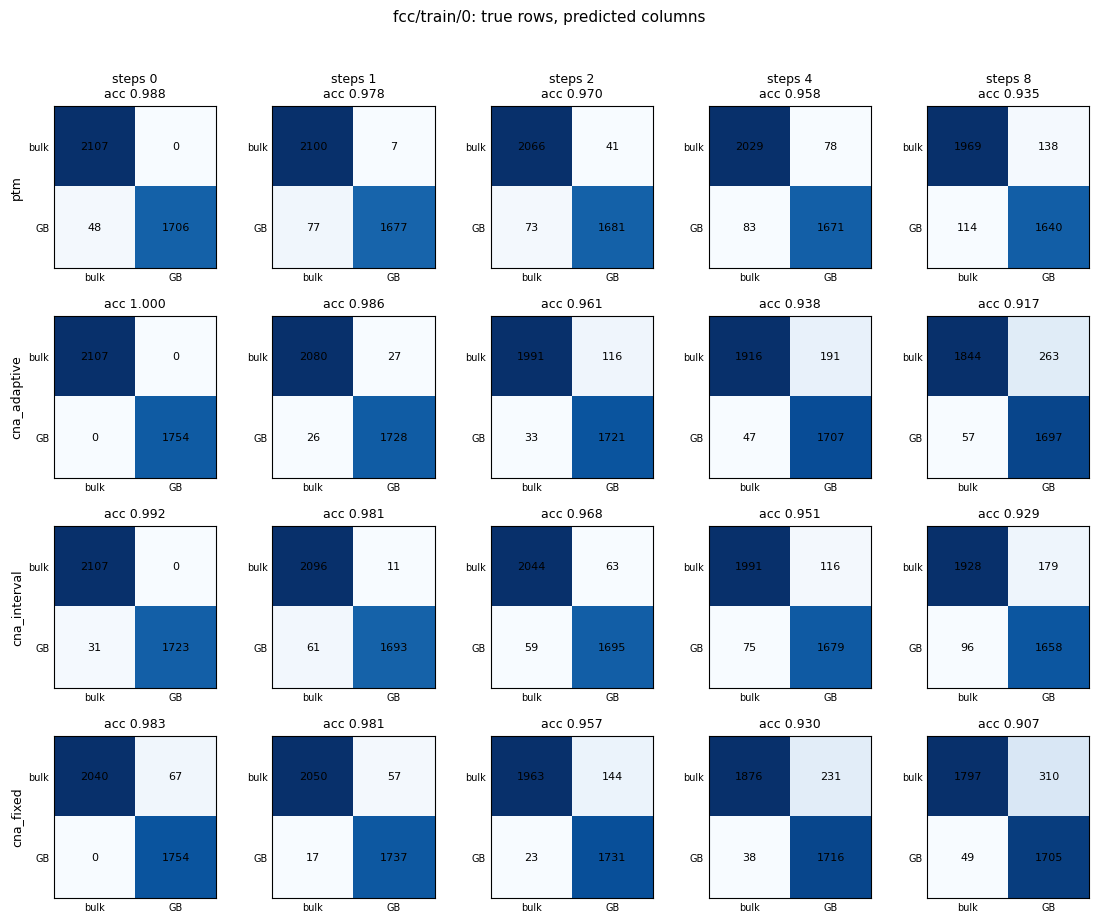

In [20]:
# Small confusion-matrix visual for PTM/CNA over the default denoising ladder
try:
    cm_fig = plot_confusion_matrices(
        selected_sample,
        cached_stage_files,
        methods=DESCRIPTOR_METHODS,
        steps=(0, 1, 2, 4, 8),
    )
    cm_fig.show()
except ImportError as exc:
    print("Matplotlib/OVITO is required for confusion matrices:", exc)
except Exception as exc:
    print("Confusion-matrix plotting failed:", type(exc).__name__, exc)

In [22]:
# All-Grains performance table: untouched vs fully denoised
# This computes descriptors one dataset at a time and only uses cached denoised dumps.
RUN_ALL_PERFORMANCE = True
PERFORMANCE_DENOISED_STEP = max(DENOISE_STEPS)
PERFORMANCE_FAMILIES = None          # e.g. ("fcc", "hcp")
PERFORMANCE_SPLITS = ("train", "target")
PERFORMANCE_MAX_SAMPLES = None       # useful for a quick test
PERFORMANCE_MAX_ATOMS = None         # set e.g. 10000 to skip huge systems while testing

if RUN_ALL_PERFORMANCE:
    all_performance = evaluate_all_grains_performance(
        denoised_step=PERFORMANCE_DENOISED_STEP,
        families=PERFORMANCE_FAMILIES,
        splits=PERFORMANCE_SPLITS,
        max_samples=PERFORMANCE_MAX_SAMPLES,
        max_atoms=PERFORMANCE_MAX_ATOMS,
    )
else:
    all_performance = pd.DataFrame()
    print("All-Grains performance evaluation is disabled. Set RUN_ALL_PERFORMANCE=True after denoised caches exist.")

if not all_performance.empty:
    for method, method_table in all_performance.groupby("method", sort=True):
        print(f"\n{method}")
        display(style_performance_table(method_table.sort_values(["dataset"])))
else:
    display(all_performance)


cna_adaptive


,dataset,accuracy_untouched,accuracy_denoised,change,status
0,Grains/bcc,1.000,0.909,-0.091,ok
1,Grains/fcc,1.000,0.924,-0.076,ok
2,Grains/hcp,1.000,0.916,-0.084,ok



cna_fixed


,dataset,accuracy_untouched,accuracy_denoised,change,status
3,Grains/bcc,0.602,0.602,+0.000,ok
4,Grains/fcc,0.983,0.917,-0.066,ok
5,Grains/hcp,0.982,0.907,-0.075,ok



cna_interval


,dataset,accuracy_untouched,accuracy_denoised,change,status
6,Grains/bcc,0.992,0.926,-0.066,ok
7,Grains/fcc,0.994,0.933,-0.061,ok
8,Grains/hcp,0.994,0.931,-0.064,ok



ptm


,dataset,accuracy_untouched,accuracy_denoised,change,status
9,Grains/bcc,0.985,0.922,-0.063,ok
10,Grains/diamond,nan,nan,+nan,missing denoised step 8
11,Grains/fcc,0.985,0.937,-0.048,ok
12,Grains/hcp,0.985,0.938,-0.047,ok


In [12]:
# Rotatable grain visualization
STRUCTURE_TYPE_NAMES = {
    0: "Other",
    1: "FCC",
    2: "HCP",
    3: "BCC",
    4: "ICO",
    5: "Cubic diamond",
    6: "Hex diamond",
}


def read_lammpstrj_frame(filename: Path, frame: int = 0) -> tuple[np.ndarray, np.ndarray]:
    """Read particle ids and xyz positions from a simple LAMMPS dump frame."""
    lines = Path(filename).read_text().splitlines()
    frame_counter = -1
    i = 0
    while i < len(lines):
        if lines[i].startswith("ITEM: TIMESTEP"):
            frame_counter += 1
            i += 2
            continue
        if lines[i].startswith("ITEM: NUMBER OF ATOMS"):
            natoms = int(lines[i + 1].strip())
            i += 2
            continue
        if lines[i].startswith("ITEM: ATOMS"):
            columns = lines[i].split()[2:]
            if frame_counter == frame:
                data_lines = lines[i + 1 : i + 1 + natoms]
                table = np.array([[float(x) for x in row.split()] for row in data_lines], dtype=float)
                col = {name: idx for idx, name in enumerate(columns)}
                ids = table[:, col.get("id", col.get("ParticleIdentifier", 0))].astype(int)
                xyz_columns = [col.get(name) for name in ("x", "y", "z")]
                if any(idx is None for idx in xyz_columns):
                    xyz_columns = [col[name] for name in ("Position.X", "Position.Y", "Position.Z")]
                positions = table[:, xyz_columns]
                order = np.argsort(ids)
                return ids[order], positions[order]
            i += 1 + natoms
            continue
        i += 1
    raise ValueError(f"Frame {frame} not found in {filename}")


def descriptor_colors(sample: GrainSample, stage_file: Path, color_by: str) -> tuple[np.ndarray, str]:
    color_by = color_by.lower()
    if color_by in {"label", "labels", "cegann"}:
        return sample.labels, "CEGANN label"
    if color_by == "ptm":
        return compute_ptm_structure_types(stage_file), "PTM structure type"
    if color_by in {"cna_adaptive", "adaptive_cna", "a-cna"}:
        return compute_cna_structure_types(stage_file, "cna_adaptive"), "adaptive CNA structure type"
    if color_by in {"cna_interval", "interval_cna", "i-cna"}:
        return compute_cna_structure_types(stage_file, "cna_interval"), "interval CNA structure type"
    if color_by in {"cna_fixed", "fixed_cna", "f-cna"}:
        return compute_cna_structure_types(stage_file, "cna_fixed", fixed_cutoff=fixed_cna_cutoff_for_sample(sample)), "fixed CNA structure type"
    raise ValueError(f"Unknown color mode {color_by!r}")


def plot_stage_grid(
    stage_files: dict[int, Path],
    sample: GrainSample,
    steps: tuple[int, ...] | None = VISUALIZATION_STEPS,
    color_by: str = "label",
    max_points: int = 9000,
    marker_size: float = 5.5,
    panel_width: int = 255,
    height: int = 340,
):
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots

    available = {int(k): Path(v) for k, v in stage_files.items() if Path(v).exists()}
    if steps is not None:
        available = {int(k): available[int(k)] for k in steps if int(k) in available}
    if not available:
        raise ValueError("No cached stage files are available to plot.")

    sorted_steps = sorted(available)
    specs = [[{"type": "scene"} for _ in sorted_steps]]
    titles = ["raw" if s == 0 else f"{s} steps" for s in sorted_steps]
    fig = make_subplots(rows=1, cols=len(sorted_steps), specs=specs, subplot_titles=titles, horizontal_spacing=0.01)

    rng = np.random.default_rng(0)
    keep = None
    if sample.natoms > max_points:
        keep = np.sort(rng.choice(sample.natoms, size=max_points, replace=False))

    for col, step_count in enumerate(sorted_steps, start=1):
        stage_file = available[step_count]
        _, positions = read_lammpstrj_frame(stage_file)
        colors, color_title = descriptor_colors(sample, stage_file, color_by)
        if keep is not None:
            positions = positions[keep]
            colors = colors[keep]
        fig.add_trace(
            go.Scatter3d(
                x=positions[:, 0],
                y=positions[:, 1],
                z=positions[:, 2],
                mode="markers",
                marker={
                    "size": marker_size,
                    "color": colors,
                    "colorscale": "Viridis",
                    "opacity": 0.98,
                    "line": {"width": 0},
                    "colorbar": {"title": color_title, "len": 0.65, "thickness": 10} if col == len(sorted_steps) else None,
                },
                text=[str(STRUCTURE_TYPE_NAMES.get(int(c), int(c))) for c in colors],
                showlegend=False,
            ),
            row=1,
            col=col,
        )
        scene_name = "scene" if col == 1 else f"scene{col}"
        fig.update_layout(
            **{
                scene_name: {
                    "aspectmode": "data",
                    "xaxis": {"title": "", "showticklabels": False},
                    "yaxis": {"title": "", "showticklabels": False},
                    "zaxis": {"title": "", "showticklabels": False},
                }
            }
        )

    fig.update_layout(
        height=height,
        width=max(panel_width * len(sorted_steps), 620),
        margin={"l": 0, "r": 0, "t": 32, "b": 0},
    )
    return fig


def plot_single_stage(stage_file: Path, sample: GrainSample, color_by: str = "label", max_points: int = 15000):
    return plot_stage_grid({0: stage_file}, sample, steps=(0,), color_by=color_by, max_points=max_points, marker_size=5.5)


# Examples:
# plot_stage_grid(cached_stage_files, selected_sample, color_by="label")
plot_stage_grid(cached_stage_files, selected_sample, color_by="ptm")
# plot_stage_grid(cached_stage_files, selected_sample, color_by="a-cna")

In [13]:
# Visualize a compact selected-sample denoising ladder.
# Change COLOR_BY to: "label", "ptm", "a-cna", "i-cna", or "f-cna".
COLOR_BY = "ptm"
PLOT_STEPS = VISUALIZATION_STEPS

try:
    fig = plot_stage_grid(cached_stage_files, selected_sample, steps=PLOT_STEPS, color_by=COLOR_BY)
    fig.show()
except ImportError as exc:
    print("Plotly is required for interactive 3D visualization:", exc)
except Exception as exc:
    print("Visualization failed:", type(exc).__name__, exc)